## Setup

In [3]:
import cv2 #صور زي الايري
import numpy as np #حق الايري
from PIL import Image #تتعامل مع الصةر طبيعي
from skimage import data
import matplotlib.pyplot as plt #لعرض الصور

%matplotlib inline

---
## Section 1 — Image Sampling and Quantization

- **Sampling** = how many pixels we keep (spatial resolution).
- **Quantization** = how many gray levels we keep (intensity resolution).

In [5]:
def sample_image(image, factor):
    """Downsamples the image by the given factor."""
    height, width = image.shape[:2] #يعطي معلومات عن الطول و العرض
    sampled_image = cv2.resize(image, (width // factor, height // factor), interpolation=cv2.INTER_NEAREST) #نصغر الصورة
    return sampled_image


def quantize_image(image, levels):
    """Reduces the number of grayscale levels in the image."""
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    quantized_image = quantized_image.astype(np.uint8) #لازم يصير انتجر مو دبل"
    return quantized_image


def plot_images(original, sampled, quantized):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1), plt.imshow(original, cmap='gray')
    plt.title('Original Image'), plt.axis('off')

    plt.subplot(1, 3, 2), plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image'), plt.axis('off')

    plt.subplot(1, 3, 3), plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image'), plt.axis('off')

    plt.show()

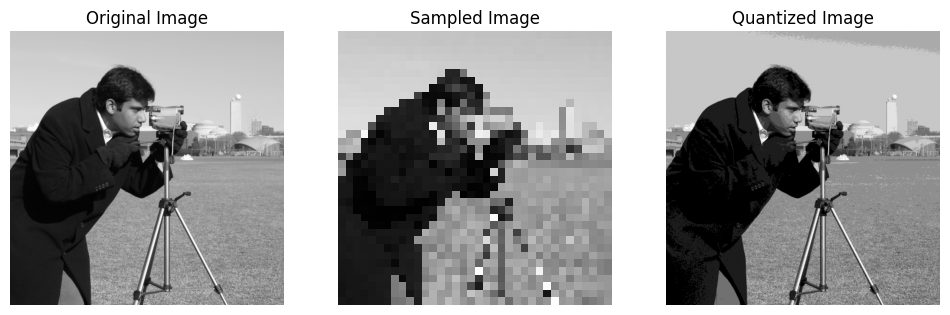

In [ ]:
"اتوقع اهم فقرة في القسم الاول"

original_image = data.camera()

sampling_factor = 14
quantization_levels = 9

sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

plot_images(original_image, sampled_image, quantized_image)

---
## Section 2 — Arithmetic Operations

Add two images by converting them to numpy arrays and adding element-wise.

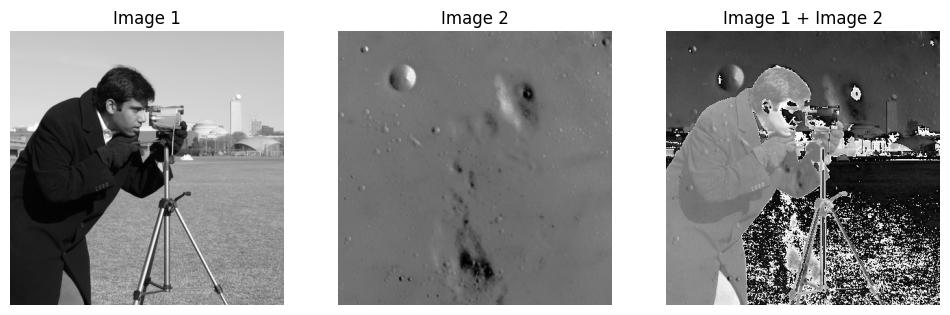

In [24]:
img1 = Image.fromarray(data.camera()) #يحول الصور من ايري الى صورة عادية"
img2 = Image.fromarray(data.moon())

new_size = (400, 400)
img1 = img1.resize(new_size, Image.Resampling.LANCZOS)
img2 = img2.resize(new_size, Image.Resampling.LANCZOS)#خليهم نفس السايز

im1arr = np.asarray(img1)
im2arr = np.asarray(img2) #نرجعها ايري"

addition = im1arr + im2arr
result_image = Image.fromarray(addition)#نرجعها صورة عشان نعرضها"

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img1, cmap='gray'), plt.title('Image 1'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img2, cmap='gray'), plt.title('Image 2'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image, cmap='gray'), plt.title('Image 1 + Image 2'), plt.axis('off')
plt.show() #عرضها"

---
## Section 3 — Set / Logical Operations

Pixel-wise bitwise operations on two images. Lab demo: **union (OR)**.

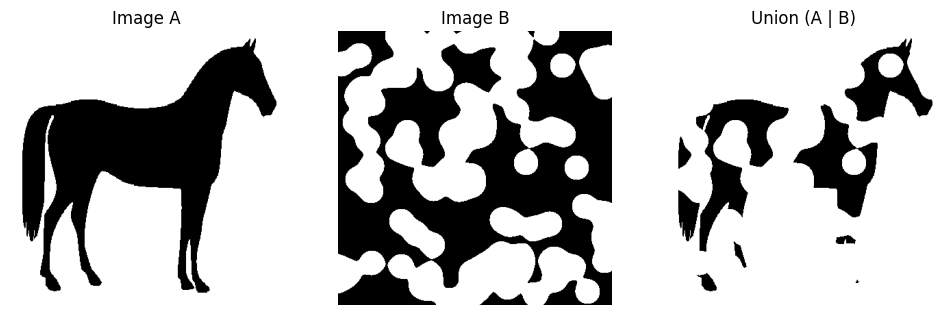

In [ ]:
#نفس فوق

img3 = Image.fromarray(data.horse())
img4 = Image.fromarray(data.binary_blobs(length=400))

img3 = img3.resize(new_size, Image.Resampling.LANCZOS)
img4 = img4.resize(new_size, Image.Resampling.LANCZOS)

im3arr = np.asarray(img3)
im4arr = np.asarray(img4)

union = im4arr | im3arr
result_image_2 = Image.fromarray(union)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img3, cmap='gray'), plt.title('Image A'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img4, cmap='gray'), plt.title('Image B'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image_2, cmap='gray'), plt.title('Union (A | B)'), plt.axis('off')
plt.show()

---
# Practical Tasks

## Task 1 — Change sampling and quantization parameters and observe the effects

Try multiple values of the sampling factor and the number of quantization levels to see how each affects the image.

### 1a) Effect of sampling factor (spatial resolution)

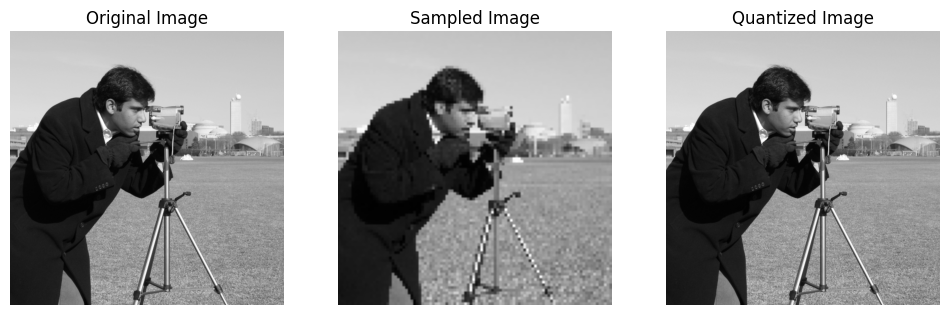

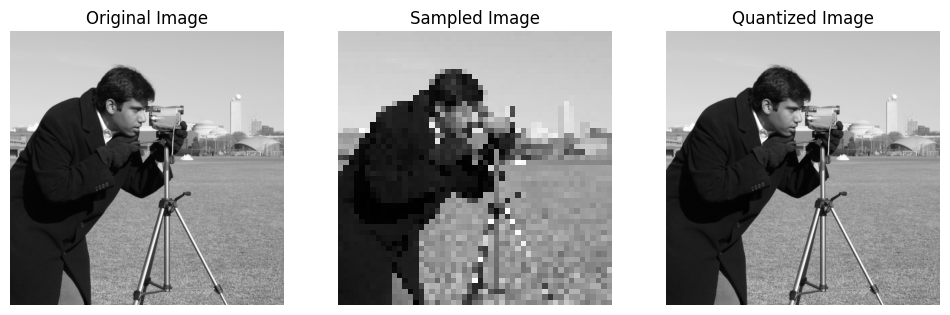

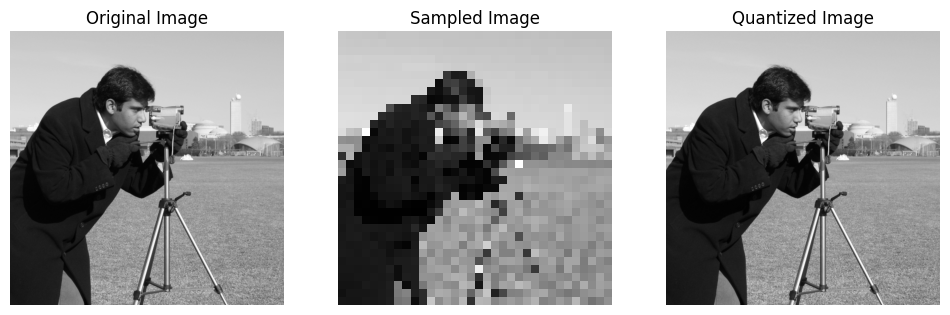

In [20]:
original_image = data.camera()

sampling_factor = 5
sampled_image = sample_image(original_image, sampling_factor)
plot_images(original_image, sampled_image,quantized_image)

sampling_factor = 10
sampled_image = sample_image(original_image, sampling_factor)
plot_images(original_image, sampled_image,quantized_image)

sampling_factor = 15
sampled_image = sample_image(original_image, sampling_factor)
plot_images(original_image, sampled_image,quantized_image)

#اتحكم في عدد البيكسل اللي تظهرو كل ما زاد الفاكتور قل الوضوح لانه قاعدين نسوي downsampling

### 1b) Effect of quantization levels (intensity resolution)

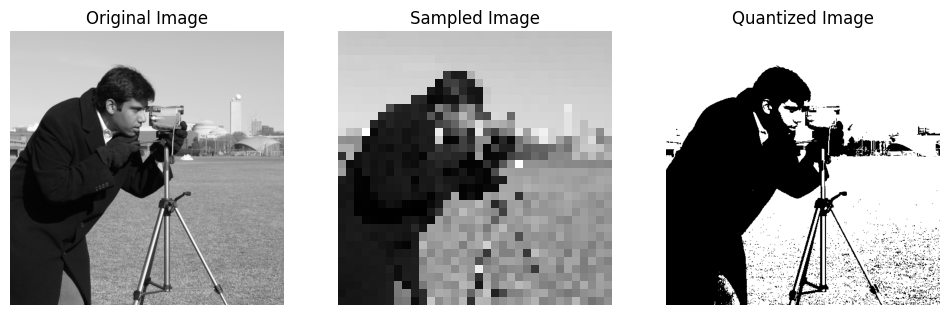

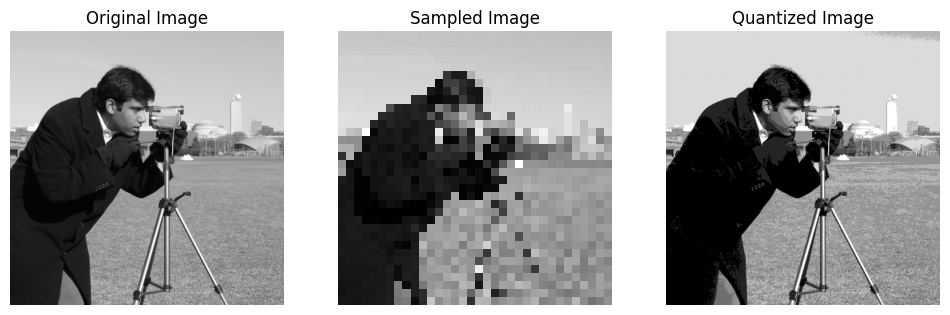

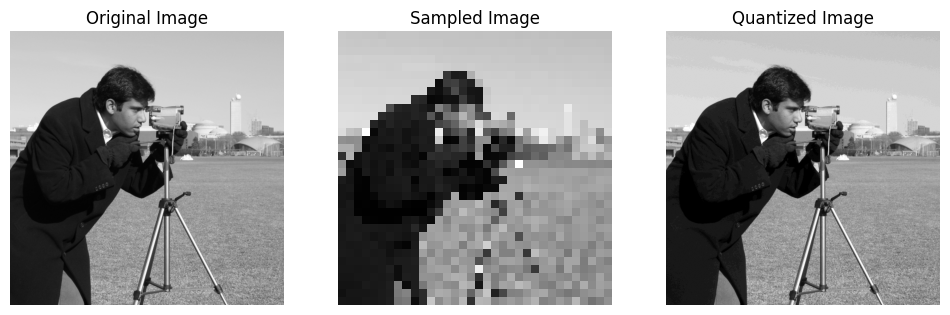

In [23]:
original_image = data.camera()

quantization_levels = 2
quantized_image = quantize_image(original_image, quantization_levels)
plot_images(original_image, sampled_image, quantized_image)

quantization_levels = 8
quantized_image = quantize_image(original_image, quantization_levels)
plot_images(original_image, sampled_image, quantized_image)

quantization_levels = 32
quantized_image = quantize_image(original_image, quantization_levels)
plot_images(original_image, sampled_image, quantized_image)

#قاعدة اتحكم في درجات اللون المسموحة, كل ما قل يعني درجات اقل مسموح انها تظهر و كل ما زاد يعني درجات اعلى مسموح انه تظهر

---
## Task 2 — Image Arithmetic and Set Operations

Required operations:
1. Subtract two images and display the result
2. Add one image with a constant value 175
3. Set difference on two grayscale images
4. Symmetric difference on two grayscale images
5. Intersection on two grayscale images

### 2a) Subtract two images

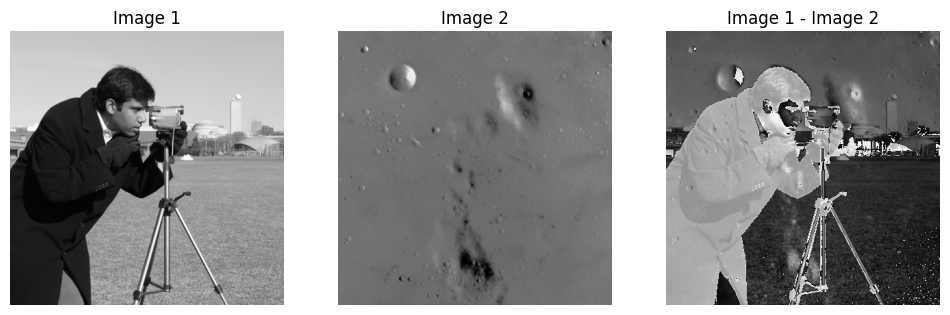

In [29]:
img1 = Image.fromarray(data.camera()) #يحول الصور من ايري الى صورة عادية"
img2 = Image.fromarray(data.moon())

new_size = (400, 400)
img1 = img1.resize(new_size, Image.Resampling.LANCZOS)
img2 = img2.resize(new_size, Image.Resampling.LANCZOS)#خليهم نفس السايز

im1arr = np.asarray(img1)
im2arr = np.asarray(img2) #نرجعها ايري"

Subtraction = im1arr - im2arr
result_image = Image.fromarray(Subtraction)#نرجعها صورة عشان نعرضها"

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img1, cmap='gray'), plt.title('Image 1'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img2, cmap='gray'), plt.title('Image 2'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image, cmap='gray'), plt.title('Image 1 - Image 2'), plt.axis('off')
plt.show() #عرضها"

### 2b) Add image with constant value 175

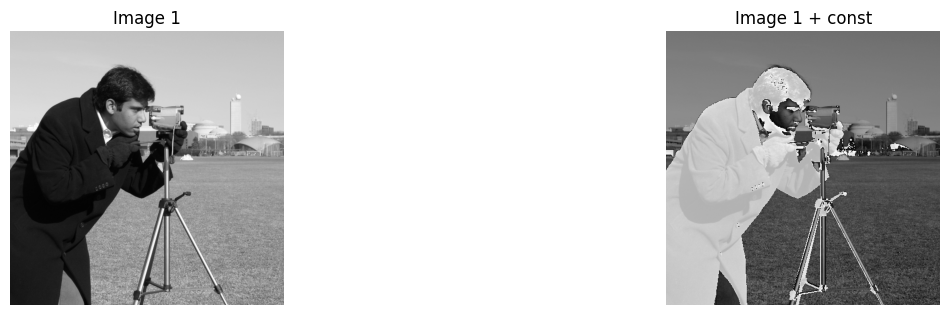

In [34]:
img1 = Image.fromarray(data.camera()) #يحول الصور من ايري الى صورة عادية"
const=175
im1arr = np.asarray(img1) #نرجعها ايري"

addition = im1arr + const
result_image = Image.fromarray(addition)#نرجعها صورة عشان نعرضها"

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img1, cmap='gray'), plt.title('Image 1'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image, cmap='gray'), plt.title('Image 1 + const'), plt.axis('off')
plt.show() #عرضها"

### 2c-2e) Set operations on grayscale images

| Operation | Bitwise formula | Meaning |
|---|---|---|
| **Intersection** | `A & B` | bits set in both |
| **Set difference** | `A & ~B` (A − B) | bits in A but not in B |
| **Symmetric difference** | `A ^ B` | bits in A or B but not both |
| **Union** (extra) | `A \| B` | bits in either |

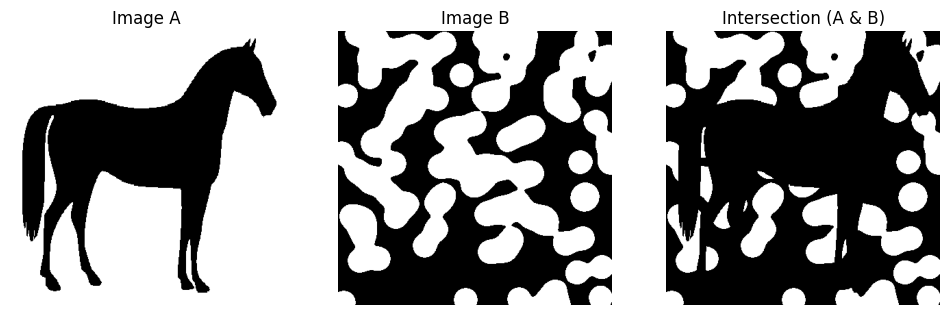

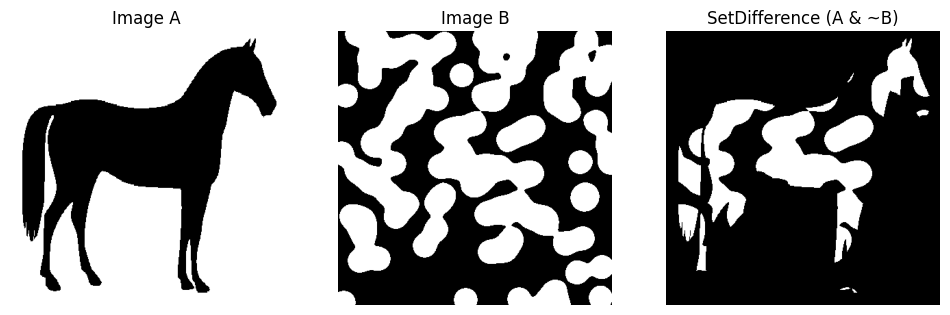

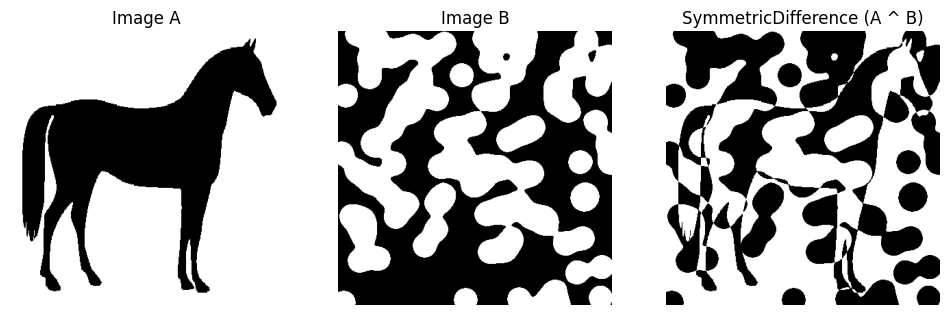

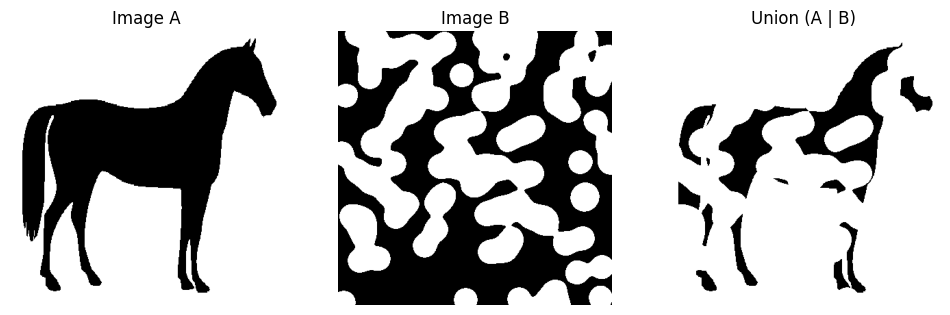

In [46]:
img3 = Image.fromarray(data.horse())
img4 = Image.fromarray(data.binary_blobs(length=400))
img3 = img3.resize(new_size, Image.Resampling.LANCZOS)
img4 = img4.resize(new_size, Image.Resampling.LANCZOS)
im3arr = np.asarray(img3)
im4arr = np.asarray(img4)

Intersection = im4arr & im3arr
result_image_2 = Image.fromarray(Intersection)
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img3, cmap='gray'), plt.title('Image A'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img4, cmap='gray'), plt.title('Image B'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image_2, cmap='gray'), plt.title('Intersection (A & B)'), plt.axis('off')
plt.show()

SetDifference = im4arr & ~im3arr
result_image_2 = Image.fromarray(SetDifference)
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img3, cmap='gray'), plt.title('Image A'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img4, cmap='gray'), plt.title('Image B'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image_2, cmap='gray'), plt.title('SetDifference (A & ~B)'), plt.axis('off')
plt.show()

SymmetricDifference = im4arr ^ im3arr
result_image_2 = Image.fromarray(SymmetricDifference)
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img3, cmap='gray'), plt.title('Image A'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img4, cmap='gray'), plt.title('Image B'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image_2, cmap='gray'), plt.title('SymmetricDifference (A ^ B)'), plt.axis('off')
plt.show()

Union = im4arr | im3arr
result_image_2 = Image.fromarray(Union)
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img3, cmap='gray'), plt.title('Image A'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img4, cmap='gray'), plt.title('Image B'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image_2, cmap='gray'), plt.title('Union (A | B)'), plt.axis('off')
plt.show()